# 02582 Computational Data Analysis — Case 1
## The High-Dimensional Standoff

**n = 100 observations, p = 100 features** — fighting the Curse of Dimensionality.

### Strategy
1. **Missing data**: `KNNImputer` with `n_neighbors` selected via cross-validation (no fixed picking)
2. **Categorical encoding**: One-hot encoding inside the pipeline (no leakage)
3. **Dimensionality reduction**: LASSO sparsity + Ridge/ElasticNet comparison
4. **Two-level cross-validation**: Outer 10-fold for unbiased RMSE estimate; inner 5-fold (GridSearchCV) for hyperparameter selection
5. **Final model**: Refit on all 100 observations with best configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
DTU_RED  = '#990000'
DTU_NAVY = '#00213E'

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading

In [2]:
DATA_DIR = Path('../data/raw')

df_train = pd.read_csv(DATA_DIR / 'case1Data.csv')
df_Xnew  = pd.read_csv(DATA_DIR / 'case1Data_Xnew.csv')

print(f'Training data shape : {df_train.shape}')
print(f'Xnew shape          : {df_Xnew.shape}')
df_train.head(3)

Training data shape : (100, 101)
Xnew shape          : (1000, 100)


,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,...,-10.200888,3.980048,-4.433274,-1.473723,NaN,74.0,72.0,72.0,73.0,73.0
1,266.811730,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,...,-9.740207,NaN,-2.629314,4.816987,-12.240248,74.0,72.0,72.0,73.0,73.0
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,...,-14.501970,10.054005,NaN,NaN,-11.107921,73.0,72.0,75.0,74.0,74.0


In [3]:
y_col    = 'y'
num_cols = [f'x_{i:02d}' for i in range(1, 96)]   # x_01 ... x_95
cat_cols = [f'C_{i:02d}' for i in range(1, 6)]    # C_01 ... C_05

y     = df_train[y_col].values
X     = df_train.drop(columns=[y_col]).copy()
X_new = df_Xnew.copy()

# Convert categoricals to strings (NaN stays as np.nan for SimpleImputer)
for col in cat_cols:
    X[col]     = X[col].apply(lambda v: str(int(v)) if pd.notna(v) else np.nan)
    X_new[col] = X_new[col].apply(lambda v: str(int(v)) if pd.notna(v) else np.nan)

print(f'n = {len(y)} observations')
print(f'Numeric features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Target y  — mean={y.mean():.2f}, std={y.std():.2f}')

n = 100 observations
Numeric features  : 95
Categorical features: 5
Target y  — mean=211.52, std=72.11


## 2. Exploratory Data Analysis

In [4]:
# Missing values summary
miss_num = X[num_cols].isnull().sum()
miss_cat = X[cat_cols].isnull().sum()

print('=== Missing values ===')
print(f'Numeric  : {miss_num.sum()} / {len(num_cols)*len(X)} cells ({miss_num.sum()/(len(num_cols)*len(X))*100:.1f}%)')
print(f'Features with >=1 missing: {(miss_num > 0).sum()} / {len(num_cols)}')
print(f'Categorical: {miss_cat.sum()} missing')
print()
print('Categorical unique values (per column):')
for col in cat_cols:
    print(f'  {col}: {sorted(X[col].dropna().unique())}  (missing: {miss_cat[col]})')

=== Missing values ===
Numeric  : 1379 / 9500 cells (14.5%)
Features with >=1 missing: 95 / 95
Categorical: 110 missing

Categorical unique values (per column):
  C_01: ['71', '72', '73', '74', '75']  (missing: 22)
  C_02: ['72']  (missing: 22)
  C_03: ['71', '72', '73', '74', '75']  (missing: 22)
  C_04: ['71', '72', '73', '74', '75']  (missing: 22)
  C_05: ['71', '72', '73', '74', '75']  (missing: 22)


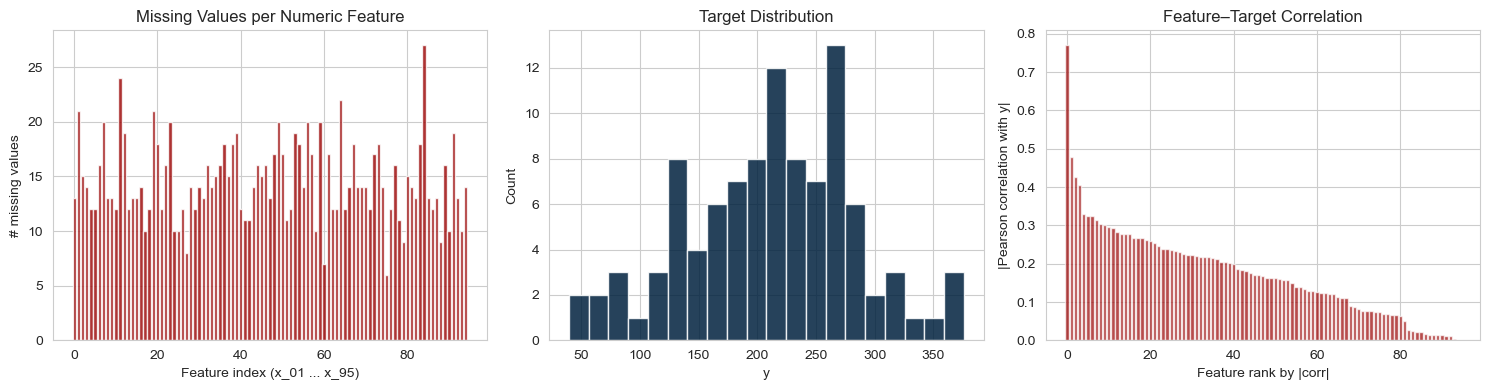

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Missing per numeric feature
axes[0].bar(range(len(num_cols)), miss_num.values, color=DTU_RED, alpha=0.8)
axes[0].set_xlabel('Feature index (x_01 ... x_95)')
axes[0].set_ylabel('# missing values')
axes[0].set_title('Missing Values per Numeric Feature')

# Target distribution
axes[1].hist(y, bins=20, color=DTU_NAVY, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Distribution')

# Correlation of numeric features with y (on available data)
corrs = X[num_cols].corrwith(pd.Series(y, index=X.index)).abs().sort_values(ascending=False)
axes[2].bar(range(len(corrs)), corrs.values, color=DTU_RED, alpha=0.7)
axes[2].set_xlabel('Feature rank by |corr|')
axes[2].set_ylabel('|Pearson correlation with y|')
axes[2].set_title('Feature–Target Correlation')

plt.tight_layout()
plt.show()

## 3. Preprocessing Pipeline

Built as a scikit-learn `Pipeline` to **prevent data leakage**: all fitting (imputer means/modes, scaler parameters) happens only on training folds, never on the test fold.

- **Numeric**: `KNNImputer(n_neighbors=k)` → `StandardScaler()`  
  `k` is treated as a hyperparameter and selected by the inner CV.
- **Categorical**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')`

In [6]:
num_pipeline = Pipeline([
    ('imputer', KNNImputer()),         # n_neighbors tuned in inner CV
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

print('Preprocessing pipeline defined.')
print('KNNImputer n_neighbors will be selected in the inner cross-validation loop.')

Preprocessing pipeline defined.
KNNImputer n_neighbors will be selected in the inner cross-validation loop.


## 4. Two-Level Cross-Validation

```
Outer loop  (K=10 folds) — estimates generalisation RMSE  →  RMSEhat
  └─ Inner loop  (K=5 folds via GridSearchCV) — selects hyperparameters
        ├─ LASSO     : alpha ∈ [1e-2, 1e2]  ×  n_neighbors ∈ {3,5,7,10}
        ├─ Ridge     : alpha ∈ [1e-2, 1e4]  ×  n_neighbors ∈ {3,5,7,10}
        └─ ElasticNet: alpha ∈ [1e-2, 1e2]  ×  l1_ratio ∈ {0.1,..,0.9}  ×  n_neighbors ∈ {3,5,7,10}
```

### Why two levels?
A single inner CV selects hyperparameters but its error is **optimistic** (we picked the best).  
The outer folds evaluate the *selected* model on held-out data that was **never seen** during selection, giving an unbiased RMSE estimate.

In [7]:
# Define model configs (pipeline template + hyperparameter grid)
knn_grid = [3, 5, 7, 10]

model_configs = {
    'LASSO': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', Lasso(max_iter=20000))
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__alpha': np.logspace(-2, 2, 20)
        }
    },
    'Ridge': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', Ridge())
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__alpha': np.logspace(-2, 4, 20)
        }
    },
    'ElasticNet': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', ElasticNet(max_iter=20000))
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__alpha':    np.logspace(-2, 2, 10),
            'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    'DecisionTree': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', DecisionTreeRegressor())
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__max_depth':        [2, 3, 5, 7, 10, None],
            'model__min_samples_leaf': [1, 2, 5, 10]
        }
    },
    'RandomForest': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__n_estimators':     [100, 300],
            'model__max_features':     ['sqrt', 0.3],
            'model__min_samples_leaf': [3, 5, 10]
        }
    },
    'GradBoost': {
        'estimator': Pipeline([
            ('pre', clone(preprocessor)),
            ('model', HistGradientBoostingRegressor(random_state=42))
        ]),
        'param_grid': {
            'pre__num__imputer__n_neighbors': knn_grid,
            'model__learning_rate':    [0.05, 0.1, 0.2],
            'model__max_iter':         [100, 300],
            'model__max_depth':        [3, 5, None],
            'model__min_samples_leaf': [10, 20]
        }
    }
}

print('Model configs:')
for name, cfg in model_configs.items():
    n_combos = 1
    for v in cfg['param_grid'].values():
        n_combos *= len(v)
    print(f'  {name:14s}: {n_combos} hyperparameter combinations x 5 inner folds = {n_combos*5} fits per outer fold')


Model configs:
  LASSO         : 80 hyperparameter combinations x 5 inner folds = 400 fits per outer fold
  Ridge         : 80 hyperparameter combinations x 5 inner folds = 400 fits per outer fold
  ElasticNet    : 200 hyperparameter combinations x 5 inner folds = 1000 fits per outer fold
  DecisionTree  : 96 hyperparameter combinations x 5 inner folds = 480 fits per outer fold
  RandomForest  : 48 hyperparameter combinations x 5 inner folds = 240 fits per outer fold
  GradBoost     : 144 hyperparameter combinations x 5 inner folds = 720 fits per outer fold


In [8]:
K_outer = 10
K_inner = 5

outer_kf = KFold(n_splits=K_outer, shuffle=True, random_state=42)

# Storage
results = {name: {'outer_rmse': [], 'best_params': [], 'best_inner_rmse': []}
           for name in model_configs}

print(f'=== Two-Level CV  (outer={K_outer}, inner={K_inner}) ===')
print(f'Comparing: {", ".join(model_configs.keys())}\n')

for fold_i, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    print(f'Outer fold {fold_i+1}/{K_outer}  (train={len(train_idx)}, test={len(test_idx)})')

    for model_name, cfg in model_configs.items():
        # Inner CV: GridSearchCV selects best hyperparameters on X_tr
        gs = GridSearchCV(
            estimator=clone(cfg['estimator']),
            param_grid=cfg['param_grid'],
            cv=K_inner,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            refit=True   # refit best model on full X_tr
        )
        gs.fit(X_tr, y_tr)

        # Evaluate on held-out outer test fold
        y_pred = gs.predict(X_te)
        rmse_outer = np.sqrt(mean_squared_error(y_te, y_pred))
        rmse_inner = np.sqrt(-gs.best_score_)

        results[model_name]['outer_rmse'].append(rmse_outer)
        results[model_name]['best_params'].append(gs.best_params_)
        results[model_name]['best_inner_rmse'].append(rmse_inner)

        print(f'  {model_name:12s}: outer RMSE={rmse_outer:.3f}  inner RMSE={rmse_inner:.3f}')

    print()

print('=== Done ===')

=== Two-Level CV  (outer=10, inner=5) ===
Comparing: LASSO, Ridge, ElasticNet, DecisionTree, RandomForest, GradBoost

Outer fold 1/10  (train=90, test=10)
  LASSO       : outer RMSE=28.772  inner RMSE=27.006
  Ridge       : outer RMSE=34.927  inner RMSE=32.141
  ElasticNet  : outer RMSE=33.017  inner RMSE=29.964
  DecisionTree: outer RMSE=62.227  inner RMSE=55.718
  RandomForest: outer RMSE=58.067  inner RMSE=54.974
  GradBoost   : outer RMSE=44.104  inner RMSE=46.096

Outer fold 2/10  (train=90, test=10)
  LASSO       : outer RMSE=33.586  inner RMSE=24.902
  Ridge       : outer RMSE=35.004  inner RMSE=28.095
  ElasticNet  : outer RMSE=33.528  inner RMSE=26.590
  DecisionTree: outer RMSE=58.683  inner RMSE=54.722
  RandomForest: outer RMSE=59.840  inner RMSE=55.256
  GradBoost   : outer RMSE=47.118  inner RMSE=45.669

Outer fold 3/10  (train=90, test=10)
  LASSO       : outer RMSE=18.382  inner RMSE=28.134
  Ridge       : outer RMSE=27.369  inner RMSE=35.150
  ElasticNet  : outer RMSE=

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.304e+01, tolerance: 3.278e+01
  model = cd_fast.enet_coordinate_descent(


  LASSO       : outer RMSE=29.298  inner RMSE=28.377
  Ridge       : outer RMSE=39.707  inner RMSE=31.054
  ElasticNet  : outer RMSE=37.035  inner RMSE=28.416
  DecisionTree: outer RMSE=47.337  inner RMSE=52.566
  RandomForest: outer RMSE=52.370  inner RMSE=52.087
  GradBoost   : outer RMSE=43.560  inner RMSE=42.907

Outer fold 5/10  (train=90, test=10)
  LASSO       : outer RMSE=20.361  inner RMSE=28.118
  Ridge       : outer RMSE=19.475  inner RMSE=33.615
  ElasticNet  : outer RMSE=19.655  inner RMSE=31.328
  DecisionTree: outer RMSE=52.126  inner RMSE=56.252
  RandomForest: outer RMSE=27.077  inner RMSE=56.731
  GradBoost   : outer RMSE=30.480  inner RMSE=43.554

Outer fold 6/10  (train=90, test=10)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.918e+01, tolerance: 3.978e+01
  model = cd_fast.enet_coordinate_descent(


  LASSO       : outer RMSE=20.319  inner RMSE=28.838
  Ridge       : outer RMSE=24.186  inner RMSE=34.481
  ElasticNet  : outer RMSE=23.753  inner RMSE=32.890
  DecisionTree: outer RMSE=36.469  inner RMSE=55.945
  RandomForest: outer RMSE=33.347  inner RMSE=56.503
  GradBoost   : outer RMSE=26.854  inner RMSE=44.648

Outer fold 7/10  (train=90, test=10)


...

  LASSO       : outer RMSE=27.326  inner RMSE=28.372
  Ridge       : outer RMSE=34.670  inner RMSE=32.372
  ElasticNet  : outer RMSE=32.014  inner RMSE=30.808
  DecisionTree: outer RMSE=68.288  inner RMSE=52.622
  RandomForest: outer RMSE=69.758  inner RMSE=53.769
  GradBoost   : outer RMSE=52.891  inner RMSE=42.314

Outer fold 8/10  (train=90, test=10)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.184e+02, tolerance: 3.954e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.113e+01, tolerance: 3.954e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.260e+01, toler

  LASSO       : outer RMSE=23.103  inner RMSE=27.426
  Ridge       : outer RMSE=26.665  inner RMSE=34.668


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.754e+01, tolerance: 3.954e+01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.540e+01, tolerance: 3.954e+01
  model = cd_fast.enet_coordinate_descent(


  ElasticNet  : outer RMSE=23.737  inner RMSE=32.665
  DecisionTree: outer RMSE=82.637  inner RMSE=53.736
  RandomForest: outer RMSE=64.820  inner RMSE=55.393
  GradBoost   : outer RMSE=49.308  inner RMSE=44.658

Outer fold 9/10  (train=90, test=10)
  LASSO       : outer RMSE=28.156  inner RMSE=27.345
  Ridge       : outer RMSE=23.843  inner RMSE=38.405
  ElasticNet  : outer RMSE=23.241  inner RMSE=33.584
  DecisionTree: outer RMSE=26.609  inner RMSE=50.342
  RandomForest: outer RMSE=53.224  inner RMSE=55.823
  GradBoost   : outer RMSE=33.019  inner RMSE=42.919

Outer fold 10/10  (train=90, test=10)
  LASSO       : outer RMSE=33.890  inner RMSE=24.979
  Ridge       : outer RMSE=34.854  inner RMSE=29.511
  ElasticNet  : outer RMSE=33.631  inner RMSE=26.704
  DecisionTree: outer RMSE=52.375  inner RMSE=54.685
  RandomForest: outer RMSE=60.085  inner RMSE=54.379
  GradBoost   : outer RMSE=48.994  inner RMSE=42.551

=== Done ===


## 5. Cross-Validation Results

In [9]:
print('=== Outer 10-fold RMSE Summary ===')
print(f'{"Model":<14} {"Mean RMSE":>10} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 50)

summary = {}
for name, res in results.items():
    rmse_arr = np.array(res['outer_rmse'])
    summary[name] = {
        'mean': rmse_arr.mean(),
        'std':  rmse_arr.std(),
        'min':  rmse_arr.min(),
        'max':  rmse_arr.max(),
        'arr':  rmse_arr
    }
    print(f'{name:<14} {rmse_arr.mean():>10.3f} {rmse_arr.std():>8.3f} {rmse_arr.min():>8.3f} {rmse_arr.max():>8.3f}')

# Best model by mean outer RMSE
best_model_name = min(summary, key=lambda k: summary[k]['mean'])
print(f'\n=> Best model: {best_model_name} (mean outer RMSE = {summary[best_model_name]["mean"]:.3f})')

=== Outer 10-fold RMSE Summary ===
Model           Mean RMSE      Std      Min      Max
--------------------------------------------------
LASSO              26.319    5.237   18.382   33.890
Ridge              30.070    6.240   19.475   39.707
ElasticNet         28.145    5.928   19.655   37.035
DecisionTree       52.749   15.434   26.609   82.637
RandomForest       51.070   14.145   27.077   69.758
GradBoost          40.199    9.650   25.666   52.891

=> Best model: LASSO (mean outer RMSE = 26.319)


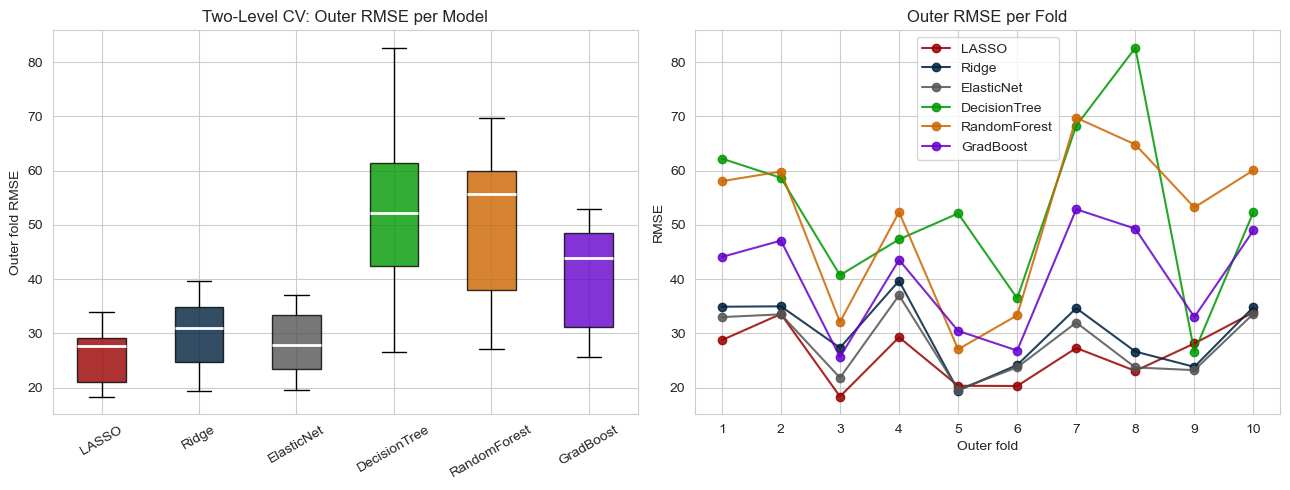

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(results.keys())
# Extended palette for up to 6 models
colors = [DTU_RED, DTU_NAVY, '#555555', '#009900', '#cc6600', '#6600cc']
colors = colors[:len(model_names)]  # trim to however many models exist

# Box plot
bp_data = [np.array(results[n]['outer_rmse']) for n in model_names]
bp = axes[0].boxplot(bp_data, labels=model_names, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[0].set_ylabel('Outer fold RMSE')
axes[0].set_title('Two-Level CV: Outer RMSE per Model')
axes[0].tick_params(axis='x', rotation=30)

# Fold-by-fold comparison
folds = np.arange(1, K_outer + 1)
for name, c in zip(model_names, colors):
    axes[1].plot(folds, results[name]['outer_rmse'], 'o-', color=c, label=name, alpha=0.85)
axes[1].set_xlabel('Outer fold')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Outer RMSE per Fold')
axes[1].legend()
axes[1].set_xticks(folds)

plt.tight_layout()
plt.show()


In [11]:
# Most frequently selected hyperparameters across outer folds
print(f'=== Hyperparameter selection — {best_model_name} ===')

all_params = results[best_model_name]['best_params']
param_keys = list(all_params[0].keys())

for key in param_keys:
    vals = [p[key] for p in all_params]
    from collections import Counter
    counts = Counter(vals)
    most_common_val = counts.most_common(1)[0][0]
    print(f'  {key}')
    for v, c in sorted(counts.items(), key=lambda x: -x[1]):
        bar = '|' * c
        print(f'    {str(v):>12}  {bar} ({c}/{K_outer} folds)')
    print()

=== Hyperparameter selection — LASSO ===
  model__alpha
    0.7847599703514611  |||| (4/10 folds)
    1.2742749857031335  ||| (3/10 folds)
    0.4832930238571752  | (1/10 folds)
    2.06913808111479  | (1/10 folds)
    0.29763514416313175  | (1/10 folds)

  pre__num__imputer__n_neighbors
               5  |||| (4/10 folds)
               7  |||| (4/10 folds)
              10  || (2/10 folds)



## 6. Final Model

The best model type is selected by comparing mean outer RMSE.  
We now **refit on all 100 training observations** using the hyperparameters most frequently selected during the outer CV.

In [12]:
# Most frequently selected hyperparameters (mode across outer folds)
from collections import Counter

def mode_params(param_list):
    keys = list(param_list[0].keys())
    return {k: Counter([p[k] for p in param_list]).most_common(1)[0][0] for k in keys}

final_params = mode_params(results[best_model_name]['best_params'])
print(f'Final model: {best_model_name}')
print(f'Final hyperparameters: {final_params}')

# Build final pipeline with selected parameters
final_pipeline = clone(model_configs[best_model_name]['estimator'])
final_pipeline.set_params(**final_params)
final_pipeline.fit(X, y)

# In-sample RMSE (for reference only — not the reported estimate)
y_train_pred = final_pipeline.predict(X)
rmse_train = np.sqrt(mean_squared_error(y, y_train_pred))
print(f'\nIn-sample RMSE (informational only): {rmse_train:.3f}')
print(f'Estimated test RMSE (RMSEhat from outer CV): {summary[best_model_name]["mean"]:.3f}')

Final model: LASSO
Final hyperparameters: {'model__alpha': np.float64(0.7847599703514611), 'pre__num__imputer__n_neighbors': 5}

In-sample RMSE (informational only): 14.435
Estimated test RMSE (RMSEhat from outer CV): 26.319


Non-zero coefficients: 39 / 116
Sparsity: 66.4% of coefficients set to zero


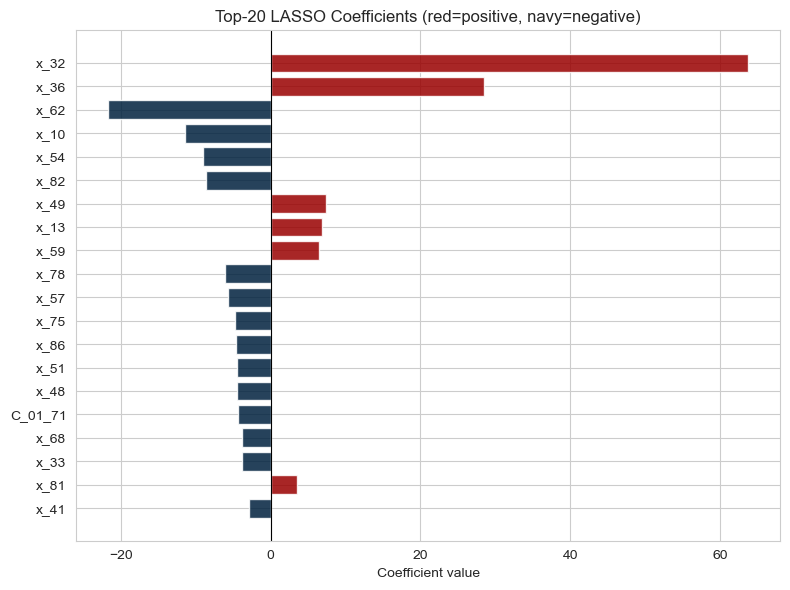

In [13]:
# Inspect coefficients for LASSO/ElasticNet (sparse solution)
model_step = final_pipeline.named_steps['model']

if hasattr(model_step, 'coef_'):
    coefs = model_step.coef_
    n_nonzero = np.sum(coefs != 0)
    print(f'Non-zero coefficients: {n_nonzero} / {len(coefs)}')
    print(f'Sparsity: {1 - n_nonzero/len(coefs):.1%} of coefficients set to zero')

    # Get feature names after OHE
    pre = final_pipeline.named_steps['pre']
    num_names = num_cols
    cat_encoder = pre.named_transformers_['cat'].named_steps['encoder']
    cat_names = list(cat_encoder.get_feature_names_out(cat_cols))
    all_feature_names = num_names + cat_names

    # Plot top-20 coefficients by magnitude
    coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    top20 = coef_df.nlargest(20, 'abs_coef')

    fig, ax = plt.subplots(figsize=(8, 6))
    bar_colors = [DTU_RED if c > 0 else DTU_NAVY for c in top20['coef']]
    ax.barh(top20['feature'], top20['coef'], color=bar_colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient value')
    ax.set_title(f'Top-20 {best_model_name} Coefficients (red=positive, navy=negative)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose coef_ attribute.')

## 7. Predictions on Xnew

Predictions shape: (1000,)
Prediction stats:  mean=199.03,  std=69.05
                   min =-14.87,  max=411.52


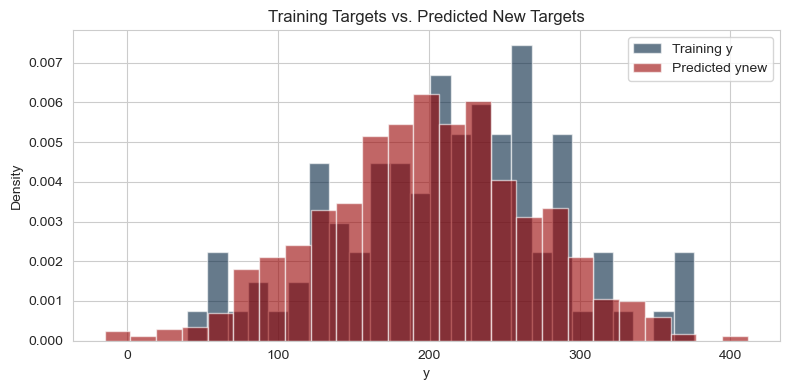

In [14]:
y_new_pred = final_pipeline.predict(X_new)

print(f'Predictions shape: {y_new_pred.shape}')
print(f'Prediction stats:  mean={y_new_pred.mean():.2f},  std={y_new_pred.std():.2f}')
print(f'                   min ={y_new_pred.min():.2f},  max={y_new_pred.max():.2f}')

# Visualise prediction distribution vs training target
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y,          bins=25, alpha=0.6, color=DTU_NAVY, label='Training y',   density=True)
ax.hist(y_new_pred, bins=25, alpha=0.6, color=DTU_RED,  label='Predicted ynew', density=True)
ax.set_xlabel('y')
ax.set_ylabel('Density')
ax.set_title('Training Targets vs. Predicted New Targets')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Prediction Files

In [ ]:
PRED_DIR = Path('../predictions')
PRED_DIR.mkdir(exist_ok=True)

STUDENT_NOS = 's253093_s253095' 

# 1. Predictions
pred_file = PRED_DIR / f'predictions_{STUDENT_NOS}.csv'
with open(pred_file, 'w') as f:
    f.write('\n'.join(str(v) for v in y_new_pred))
print(f'Predictions saved to: {pred_file}')

# 2. RMSE 
rmse_hat = summary[best_model_name]['mean']
rmse_file = PRED_DIR / f'estimatedRMSE_{STUDENT_NOS}.csv'
with open(rmse_file, 'w') as f:
    f.write(str(rmse_hat))
print(f'RMSE estimate ({rmse_hat:.4f}) saved to: {rmse_file}')

Predictions saved to: ../predictions/predictions_s253093_s253095.csv
RMSE estimate (26.3192) saved to: ../predictions/estimatedRMSE_s253093_s253095.csv


## 9. Summary

| Item | Value |
|------|-------|
| Best model | See `best_model_name` above |
| RMSE estimate (RMSEhat) | Mean outer-fold RMSE from 10-fold CV |
| Missing data handling | KNNImputer (n_neighbors selected per fold by inner CV) |
| Categorical encoding | OneHotEncoder inside pipeline |
| Hyperparameter selection | Inner 5-fold GridSearchCV |
| Generalization estimate | Outer 10-fold CV (unbiased) |

### Why LASSO handles the Curse of Dimensionality
With n=100 and p≈100+ features, OLS is ill-posed. LASSO adds an L1 penalty that **forces most coefficients to exactly zero**, selecting a sparse subset of truly predictive features and avoiding the overfitting that plagues unconstrained estimators in high dimensions.